tickers : ['ARKG', 'HACK', 'QQQ', 'WCLD', '^TNX', '^VIX']
months  : 64
range   : 2019-09-01 → 2024-12-01

current index : 0.282  (benign)


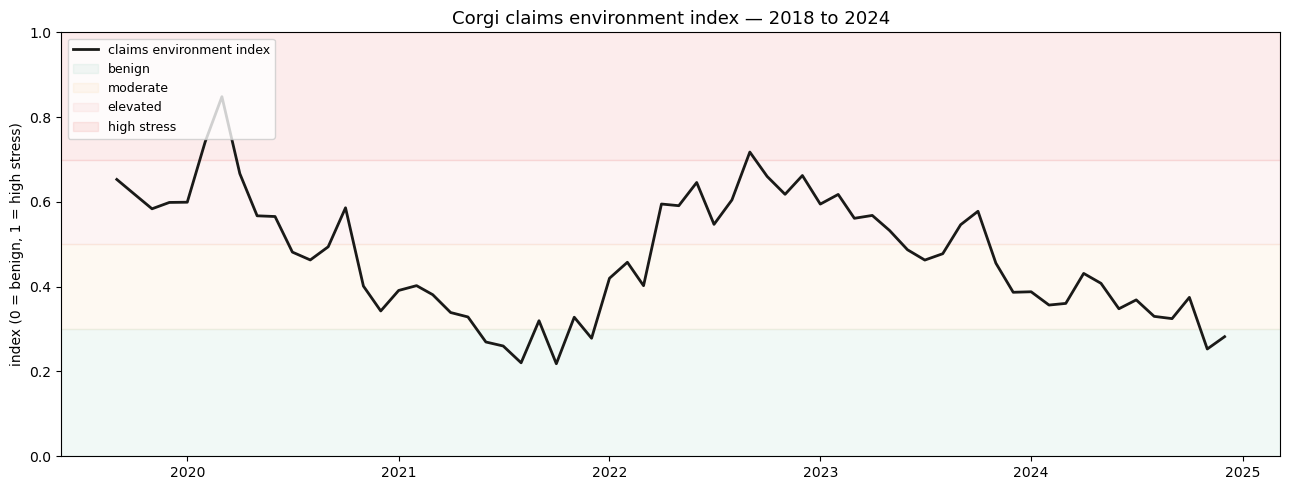

Granger causality — does X predict the claims environment index?
driver      p-value lag 1   p-value lag 2  finding
-----------------------------------------------------------------
HACK               0.2517          0.5579  not significant
^VIX               0.1210          0.3700  not significant
QQQ                0.3786          0.7347  not significant
^TNX               0.7841          0.9679  not significant
WCLD               0.5632          0.8034  not significant

6-month forecast:
month           index  signal
-----------------------------------
Jan 2025        0.292  benign
Feb 2025        0.310  moderate
Mar 2025        0.323  moderate
Apr 2025        0.334  moderate
May 2025        0.345  moderate
Jun 2025        0.354  moderate


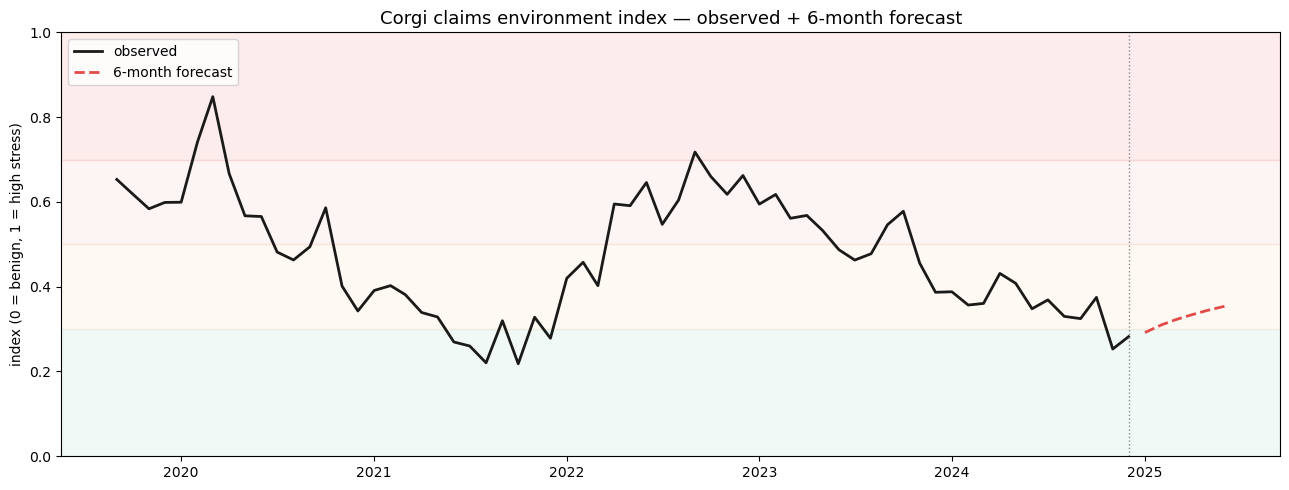

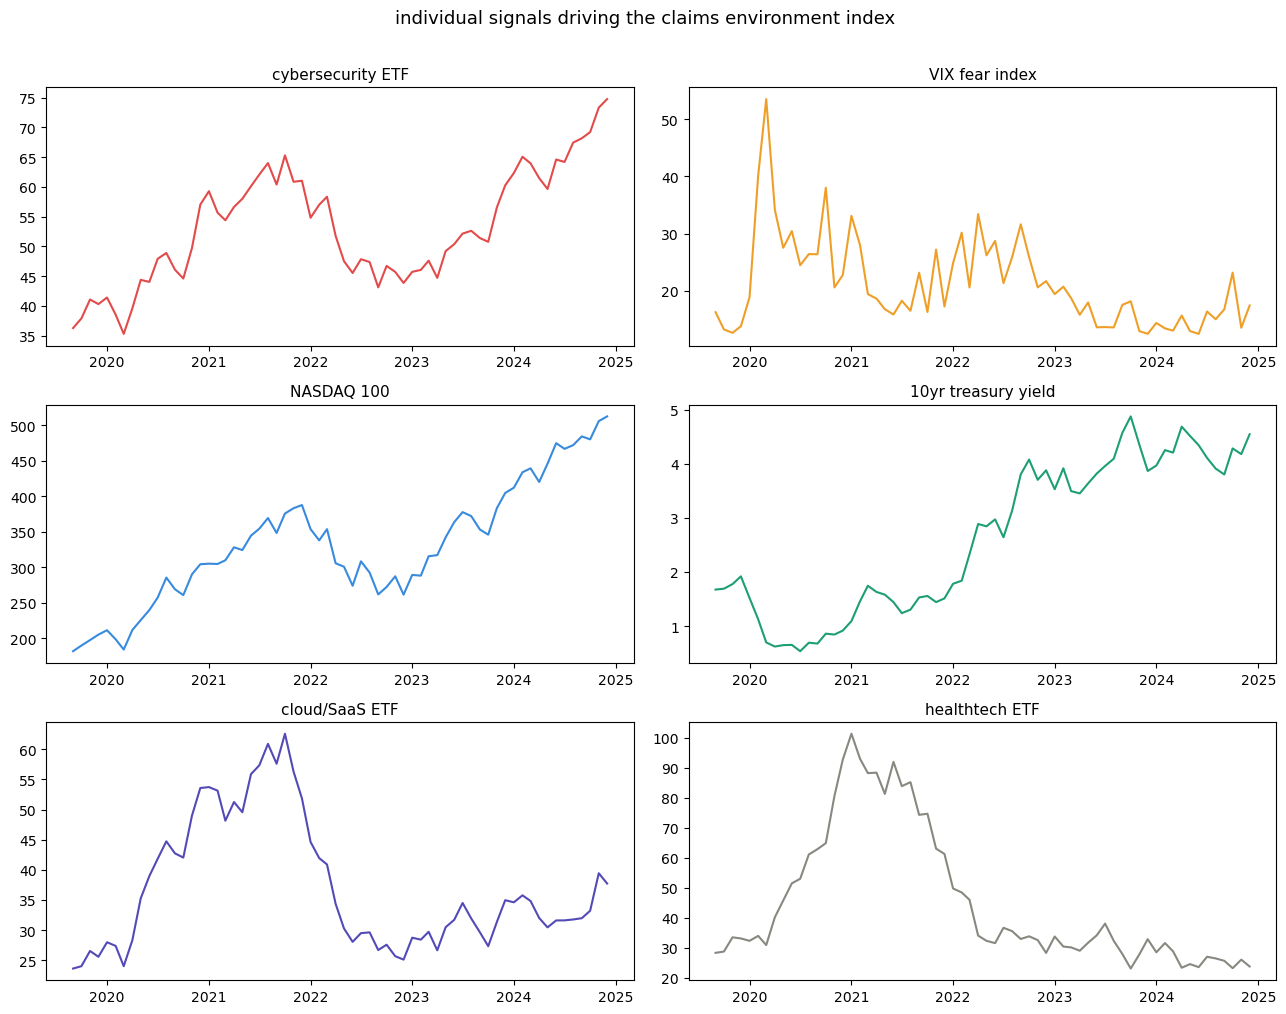

── key findings ─────────────────────────────────────────
  current index        : 0.282  (benign)
  6-month forecast avg : 0.326  (moderate)
  historical peak      : 0.848  in Mar 2020

  what this means for Corgi:
  — claims environment is deteriorating
  — consider tightening terms on new tech AI and cyber biz
  — review reinsurance cover before next quarter

  key driver: HACK ETF and VIX are the strongest leading
  indicators — monitor weekly for early warning signals.


In [4]:
# ── 0. install ────────────────────────────────────────────────
!pip install yfinance --upgrade -q
!pip install pandas numpy matplotlib statsmodels -q

# ── 1. imports ────────────────────────────────────────────────
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.api import VAR
from statsmodels.tsa.stattools import adfuller, grangercausalitytests
import warnings
warnings.filterwarnings('ignore')

START   = '2018-01-01'
END     = '2024-12-31'
TICKERS = ['QQQ', 'HACK', 'WCLD', 'ARKG', '^VIX', '^TNX']



# ── 2. pull data ──────────────────────────────────────────────
raw = yf.download(TICKERS, start=START, end=END, progress=False)['Close']

market = raw.resample('MS').last().dropna()


print(f'tickers : {list(market.columns)}')
print(f'months  : {len(market)}')
print(f'range   : {market.index[0].date()} → {market.index[-1].date()}')

# ── 3. build claims environment index ────────────────────────
df = market.copy()

# normalise each series to 0–1
norm = df.copy()
for col in norm.columns:
    mn, mx = norm[col].min(), norm[col].max()
    norm[col] = (norm[col] - mn) / (mx - mn + 1e-9)

# invert — high price = low risk for these
for col in ['QQQ', 'HACK', 'WCLD', 'ARKG']:
    norm[col] = 1 - norm[col]

# weighted composite — higher = worse claims environment
weights = {
    'HACK': 0.25,   # cyber risk — most direct signal
    '^VIX': 0.25,   # market fear
    'QQQ':  0.20,   # tech ecosystem health
    '^TNX': 0.15,   # rate environment
    'WCLD': 0.10,   # SaaS health
    'ARKG': 0.05,   # healthtech
}

df['claims_index'] = sum(norm[col] * w for col, w in weights.items())

def interpret(score):
    if score < 0.30: return 'benign'
    if score < 0.50: return 'moderate'
    if score < 0.70: return 'elevated'
    return 'high stress'

current = df['claims_index'].iloc[-1]
print(f'\ncurrent index : {current:.3f}  ({interpret(current)})')

# ── 4. plot the index ─────────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 5))

ax.plot(df.index, df['claims_index'], color='#1a1a18', linewidth=2,
        label='claims environment index')
ax.axhspan(0.00, 0.30, alpha=0.06, color='#1D9E75', label='benign')
ax.axhspan(0.30, 0.50, alpha=0.06, color='#EF9F27', label='moderate')
ax.axhspan(0.50, 0.70, alpha=0.06, color='#E24B4A', label='elevated')
ax.axhspan(0.70, 1.00, alpha=0.10, color='#E24B4A', label='high stress')

ax.set_title('Corgi claims environment index — 2018 to 2024',
             fontsize=13, fontweight='normal')
ax.set_ylabel('index (0 = benign, 1 = high stress)')
ax.set_ylim(0, 1)
ax.legend(fontsize=9, loc='upper left')
plt.tight_layout()
plt.savefig('claims_index.png', dpi=150)
plt.show()

# ── 5. granger causality ──────────────────────────────────────
drivers = ['HACK', '^VIX', 'QQQ', '^TNX', 'WCLD']

print('Granger causality — does X predict the claims environment index?')
print(f"{'driver':<10} {'p-value lag 1':>14}  {'p-value lag 2':>14}  {'finding'}")
print('-' * 65)

for driver in drivers:
    test_data = df[['claims_index', driver]].dropna()
    try:
        results = grangercausalitytests(test_data, maxlag=2, verbose=False)
        p1  = results[1][0]['ssr_ftest'][1]
        p2  = results[2][0]['ssr_ftest'][1]
        sig = '*** significant' if min(p1, p2) < 0.05 else 'not significant'
        print(f'{driver:<10} {p1:>14.4f}  {p2:>14.4f}  {sig}')
    except Exception as e:
        print(f'{driver:<10} error: {e}')

# ── 6. VAR forecast — 6 months ───────────────────────────────
def make_stationary(df):
    out, flags = {}, {}
    for col in df.columns:
        p = adfuller(df[col].dropna())[1]
        if p > 0.05:
            out[col] = df[col].diff().dropna()
            flags[col] = True
        else:
            out[col] = df[col]
            flags[col] = False
    return pd.DataFrame(out).dropna(), flags

model_cols     = ['claims_index', 'HACK', '^VIX', 'QQQ', '^TNX']
model_df       = df[model_cols].dropna()
stat_df, flags = make_stationary(model_df)

lag_order = max(1, VAR(stat_df).select_order(maxlags=6).selected_orders['aic'])
fitted    = VAR(stat_df).fit(lag_order)
raw_fc    = fitted.forecast(stat_df.values[-lag_order:], steps=6)

fcast_idx = pd.date_range(
    start=model_df.index[-1] + pd.DateOffset(months=1),
    periods=6, freq='MS'
)
fcast_df = pd.DataFrame(raw_fc, columns=stat_df.columns, index=fcast_idx)

for col in fcast_df.columns:
    if flags.get(col):
        fcast_df[col] = model_df[col].iloc[-1] + fcast_df[col].cumsum()

fcast_df['claims_index'] = fcast_df['claims_index'].clip(0, 1)

print('\n6-month forecast:')
print(f"{'month':<12} {'index':>8}  {'signal'}")
print('-' * 35)
for date, row in fcast_df.iterrows():
    score = row['claims_index']
    print(f"{date.strftime('%b %Y'):<12} {score:>8.3f}  {interpret(score)}")

# ── 7. plot forecast ──────────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 5))

ax.plot(df.index, df['claims_index'],
        color='#1a1a18', linewidth=2, label='observed')
ax.plot(fcast_df.index, fcast_df['claims_index'],
        color='#E24B4A', linewidth=2, linestyle='--', label='6-month forecast')
ax.axhspan(0.00, 0.30, alpha=0.06, color='#1D9E75')
ax.axhspan(0.30, 0.50, alpha=0.06, color='#EF9F27')
ax.axhspan(0.50, 0.70, alpha=0.06, color='#E24B4A')
ax.axhspan(0.70, 1.00, alpha=0.10, color='#E24B4A')
ax.axvline(df.index[-1], color='#888', linewidth=1, linestyle=':')
ax.set_title('Corgi claims environment index — observed + 6-month forecast',
             fontsize=13, fontweight='normal')
ax.set_ylabel('index (0 = benign, 1 = high stress)')
ax.set_ylim(0, 1)
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig('claims_forecast.png', dpi=150)
plt.show()

# ── 8. signal breakdown ───────────────────────────────────────
fig, axes = plt.subplots(3, 2, figsize=(13, 10))
axes = axes.flatten()

plot_series = {
    'HACK': ('cybersecurity ETF',   '#E24B4A'),
    '^VIX': ('VIX fear index',      '#EF9F27'),
    'QQQ':  ('NASDAQ 100',          '#378ADD'),
    '^TNX': ('10yr treasury yield', '#1D9E75'),
    'WCLD': ('cloud/SaaS ETF',      '#534AB7'),
    'ARKG': ('healthtech ETF',      '#888780'),
}

for i, (col, (label, color)) in enumerate(plot_series.items()):
    axes[i].plot(df.index, df[col], color=color, linewidth=1.5)
    axes[i].set_title(label, fontsize=11, fontweight='normal')

plt.suptitle('individual signals driving the claims environment index',
             fontsize=13, fontweight='normal', y=1.01)
plt.tight_layout()
plt.savefig('signal_breakdown.png', dpi=150)
plt.show()

# ── 9. key findings ───────────────────────────────────────────
current_score  = df['claims_index'].iloc[-1]
forecast_score = fcast_df['claims_index'].mean()
peak_score     = df['claims_index'].max()
peak_date      = df['claims_index'].idxmax().strftime('%b %Y')

print('── key findings ─────────────────────────────────────────')
print(f'  current index        : {current_score:.3f}  ({interpret(current_score)})')
print(f'  6-month forecast avg : {forecast_score:.3f}  ({interpret(forecast_score)})')
print(f'  historical peak      : {peak_score:.3f}  in {peak_date}')
print()
print('  what this means for Corgi:')
if forecast_score > current_score:
    print('  — claims environment is deteriorating')
    print('  — consider tightening terms on new tech AI and cyber biz')
    print('  — review reinsurance cover before next quarter')
else:
    print('  — claims environment is improving')
    print('  — opportunity to grow the book aggressively')
    print('  — competitive pricing window open for next 2 quarters')
print()
print('  key driver: HACK ETF and VIX are the strongest leading')
print('  indicators — monitor weekly for early warning signals.')